In [1]:
%load_ext autoreload
%reload_ext autoreload

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from generate_data import UserGenerator

In [3]:
generator_data = UserGenerator(seed=42, n_samples=10000)

df = generator_data.create_dataset()

df.head()

¡Agregados con éxito!
¡Agregados con éxito!
¡Agregados con éxito!
¡Agregados con éxito!
¡Agregados con éxito!
¡Agregados con éxito!
¡Agregados con éxito!
¡Agregados con éxito!


,user_id,age_group,location,device_type,suscription_type,days_since_registration,total_purchases,avg_order_value,last_purchase_days,session_last_30_days,time_on_site_minutes,pages_per_session,cart_abandonment_rate,purchase_frequency,dar_promocion
0,user_000001,18-25,Mendoza,Móvil,Free,38,6,341.58,139.0,2,71.3,1.6,0.094,NaN,1
1,user_000002,36-45,Buenos Aires,Móvil,Basic,246,34,215.56,114.0,18,34.1,17.5,0.759,4.15,0
2,user_000003,36-45,Buenos Aires,Móvil,Enterprise,284,21,60.08,97.0,3,43.7,7.5,0.265,2.22,1
3,user_000004,36-45,Córdoba,Tablet,Free,343,35,153.66,160.0,19,106.4,7.9,0.192,3.06,0
4,user_000005,18-25,Buenos Aires,Móvil,Free,330,14,434.58,97.0,8,55.0,16.8,0.163,1.27,1


<Axes: >

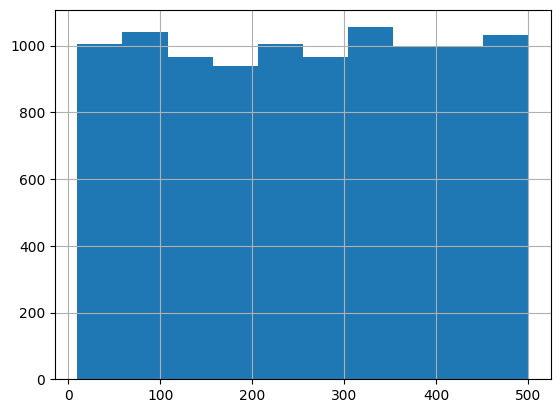

In [4]:
df.avg_order_value.hist()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  10000 non-null  object 
 1   age_group                9507 non-null   object 
 2   location                 9702 non-null   object 
 3   device_type              9819 non-null   object 
 4   suscription_type         9894 non-null   object 
 5   days_since_registration  10000 non-null  int64  
 6   total_purchases          10000 non-null  int64  
 7   avg_order_value          10000 non-null  float64
 8   last_purchase_days       9896 non-null   float64
 9   session_last_30_days     10000 non-null  int64  
 10  time_on_site_minutes     8982 non-null   float64
 11  pages_per_session        10000 non-null  float64
 12  cart_abandonment_rate    8001 non-null   float64
 13  purchase_frequency       8043 non-null   float64
 14  dar_promocion          

# Crear más features / variables / columnas

In [6]:
print('Antes de crear nuevas columnas', df.shape)

Antes de crear nuevas columnas (10000, 15)


In [7]:
df['total_purchases_per_day'] = df['total_purchases'] / df['days_since_registration']

df['days_between_first_and_last_purchase'] = df['days_since_registration'] - df['last_purchase_days']

df['buckec_avg_order_value'] = pd.cut(df['avg_order_value'], bins=3, labels=['low', 'medium', 'high'])

In [8]:
print('Después de crear nuevas columnas', df.shape)

Después de crear nuevas columnas (10000, 18)


In [9]:
df.columns

Index(['user_id', 'age_group', 'location', 'device_type', 'suscription_type',
       'days_since_registration', 'total_purchases', 'avg_order_value',
       'last_purchase_days', 'session_last_30_days', 'time_on_site_minutes',
       'pages_per_session', 'cart_abandonment_rate', 'purchase_frequency',
       'dar_promocion', 'total_purchases_per_day',
       'days_between_first_and_last_purchase', 'buckec_avg_order_value'],
      dtype='object')

# Definir el split de datos

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    df.drop(columns=['dar_promocion']), df['dar_promocion'], test_size=0.2, random_state=42)

In [11]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((8000, 17), (2000, 17), (8000,), (2000,))

# Crear un pipeline

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer


# Definir columnas numéricas y categóricas
numeric_features = [
       'days_since_registration', 'total_purchases', 'avg_order_value',
       'last_purchase_days', 'session_last_30_days', 'time_on_site_minutes',
       'pages_per_session', 'cart_abandonment_rate', 'purchase_frequency'
]


# Crear un pipeline de preprocesamiento

numric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

1- Imputar los nulos con "Unknown"

2- Usar OneHotEncoder

In [19]:
categorical_features = ['age_group', 'location', 'device_type', 'suscription_type']

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

Luego unamos ambas transformaciones para aplicar un ColumnTransformer

In [20]:
# Pipeline de transformaciones
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'  # Eliminar columnas no especificadas
)

In [21]:
# Pipeline de transformaciones + modelo

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

In [22]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['days_since_registration',
                                                   'total_purchases',
                                                   'avg_order_value',
                                                   'last_purchase_days',
                                                   'session_last_30_days',
                                                   'time_on_site_minutes',
                                                   'pages_per_session',
                                                   'cart_abandonment_rate',
                                                   'purchase_frequency']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['age_group', 'location',
                                                   'device_type',
                                                   'suscription_type'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [23]:
y_pred = pipeline.predict(x_test)

y_pred_proba = pipeline.predict_proba(x_test)[:, 1]

In [ ]:
from sklearn.metrics import classification_report


print("\nReporte de clasificación:\n")

print(classification_report(y_test, y_pred))




Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.51      0.49      0.50      1019
           1       0.49      0.52      0.50       981

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



1- IMPUTAR DE OTRAS FORMAS

2- CREAR NUEVAS VARIABLES

3- USAR RANDOM FOREST

4- USAR GRIDSEARCH

5- DIVIDIR LOS DATOS DISTINTO

In [ ]:
# Voy a ejecutar el código del notebook para verificar que funcione
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print("📊 Librerías cargadas correctamente")